# Análise de População por Município e Estado (Censo 2010 x Censo 2022)

Fonte dos dados: IBGE — Censo Demográfico 2022 (arquivo `CD2022_Populacao_2010_Compatibilizada_20231222.xlsx`).

Este notebook:
1. Lê a planilha do IBGE;
2. Agrega a população por **estado**;
3. Agrega a população por **município**;
4. Calcula a diferença de população entre 2010 e 2022 e ordena do que mais cresceu para o que menos cresceu;
5. Salva os resultados em CSV;
6. Gera gráficos comparando 2010 x 2022.

## 1. Instalação das bibliotecas

Rode esta célula **uma vez só** (ou pelo terminal). Se já tiver tudo instalado, pode pular.

In [ ]:
# Só precisa rodar isso uma vez no seu ambiente/venv.
# Pode comentar essa linha depois de instalar.
%pip install pandas openpyxl matplotlib seaborn

## 2. Importar bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Ler a tabela

A planilha do IBGE tem 2 linhas de título antes do cabeçalho de verdade, por isso usamos `header=2`
(a 3ª linha da planilha é a linha 0 em contagem do pandas).

In [ ]:
CAMINHO_ARQUIVO = "dados/CD2022_Populacao_2010_Compatibilizada_20231222__1_.xlsx"

df = pd.read_excel(CAMINHO_ARQUIVO, sheet_name="Municípios", header=2)

# Remove linhas em branco/rodapé (notas do IBGE no fim da planilha)
df = df.dropna(subset=["UF", "COD. MUNIC"]).copy()

# Renomeia colunas para nomes mais simples de usar no código
df = df.rename(columns={
    "População Município 2010\n(Sinopse)": "pop_2010_sinopse",
    "População 2010 (Alterações de Limites até 2022)1": "pop_2010_compatibilizada",
    "População Censo 2022": "pop_2022",
    "NOME DO MUNICÍPIO": "MUNICIPIO",
})

# Usamos a população 2010 "compatibilizada" (recomendação do próprio IBGE na planilha),
# pois ela já leva em conta mudanças de limites municipais entre 2010 e 2022.
col_2010 = "pop_2010_compatibilizada"
col_2022 = "pop_2022"

df[col_2010] = pd.to_numeric(df[col_2010], errors="coerce")
df[col_2022] = pd.to_numeric(df[col_2022], errors="coerce")

df.head()

## 4. Tabela agregada por ESTADO

In [ ]:
pop_estado = (
    df.groupby(["COD. UF", "UF"], as_index=False)
      .agg(
          populacao_2010=(col_2010, "sum"),
          populacao_2022=(col_2022, "sum"),
      )
)

pop_estado["diferenca_2010_2022"] = pop_estado["populacao_2022"] - pop_estado["populacao_2010"]
pop_estado["crescimento_pct"] = (pop_estado["diferenca_2010_2022"] / pop_estado["populacao_2010"] * 100).round(2)

# Ordena do estado que MAIS cresceu (em número absoluto de habitantes) para o que menos cresceu
pop_estado = pop_estado.sort_values("diferenca_2010_2022", ascending=False).reset_index(drop=True)

pop_estado.head(10)

## 5. Salvar tabela por estado em CSV

In [ ]:
pop_estado.to_csv(r"populacao_por_estado.csv", sep=";", index=False, decimal=",")
print("Arquivo salvo: populacao_por_estado.csv")

## 6. Tabela por MUNICÍPIO

In [ ]:
pop_municipio = df[["COD. UF", "UF", "COD. MUNIC", "MUNICIPIO", col_2010, col_2022]].rename(
    columns={col_2010: "populacao_2010", col_2022: "populacao_2022"}
)

pop_municipio["diferenca_2010_2022"] = pop_municipio["populacao_2022"] - pop_municipio["populacao_2010"]
pop_municipio["crescimento_pct"] = (pop_municipio["diferenca_2010_2022"] / pop_municipio["populacao_2010"] * 100).round(2)

# Ordena do município que MAIS cresceu para o que menos cresceu
pop_municipio = pop_municipio.sort_values("diferenca_2010_2022", ascending=False).reset_index(drop=True)

pop_municipio.head(10)

## 7. Salvar tabela por município em CSV

In [ ]:
pop_municipio.to_csv(r"populacao_por_municipio.csv", sep=";", index=False, decimal=",")
print("Arquivo salvo: populacao_por_municipio.csv")

## 8. Gráficos

### 8.1 Barras agrupadas — 10 estados com maior crescimento absoluto (2010 x 2022)

Obs: como São Paulo e Minas Gerais têm uma população muito maior que os demais estados,
a escala do gráfico fica "achatada" para os outros. Isso é normal — o gráfico mostra
**crescimento absoluto** (nº de habitantes a mais), não percentual.

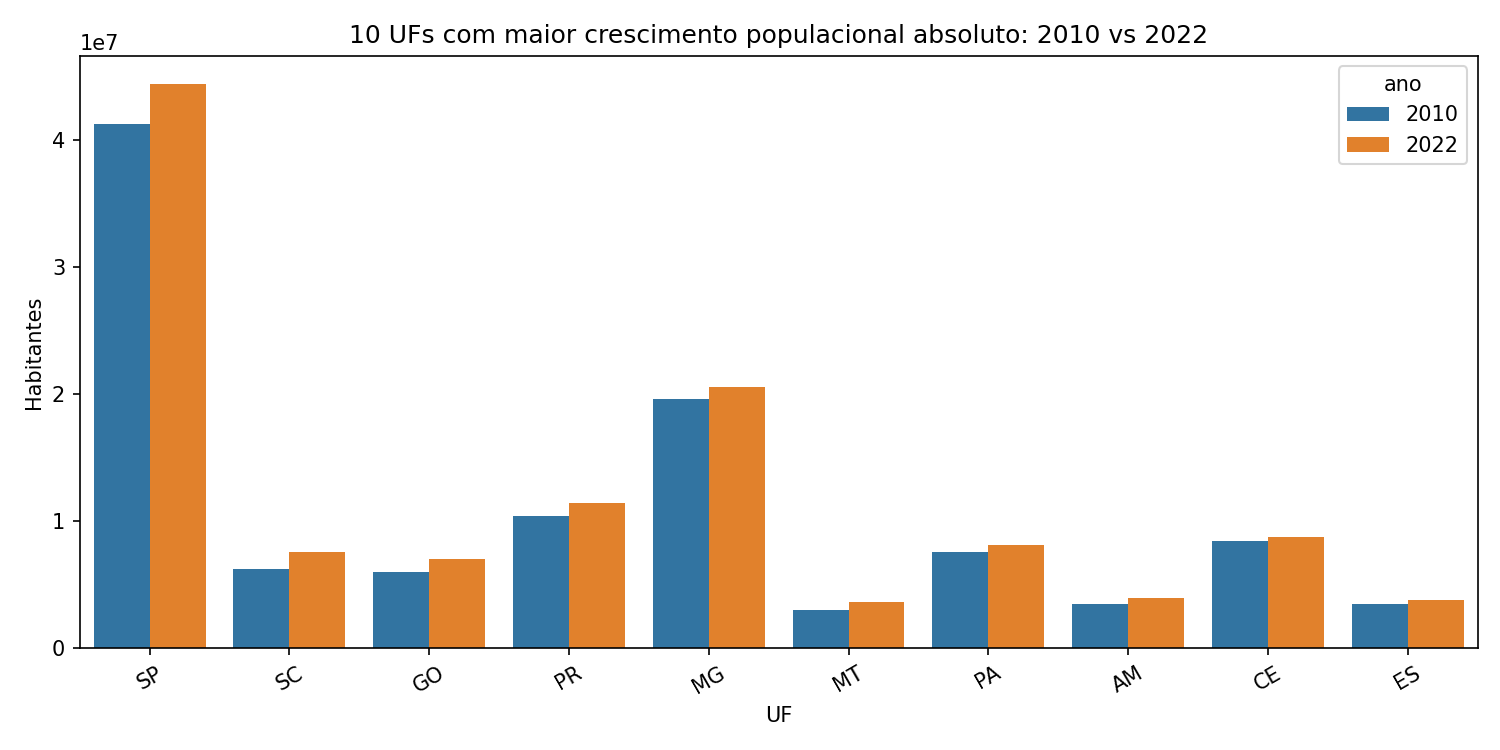

In [ ]:
top = pop_estado.head(10).melt(
    id_vars="UF",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)
top["ano"] = top["ano"].map({"populacao_2010": "2010", "populacao_2022": "2022"})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("grafico_top10_estados_2010_2022.png", dpi=150)
plt.show()

### 8.2 Diferença absoluta de população por estado (todos os 27)

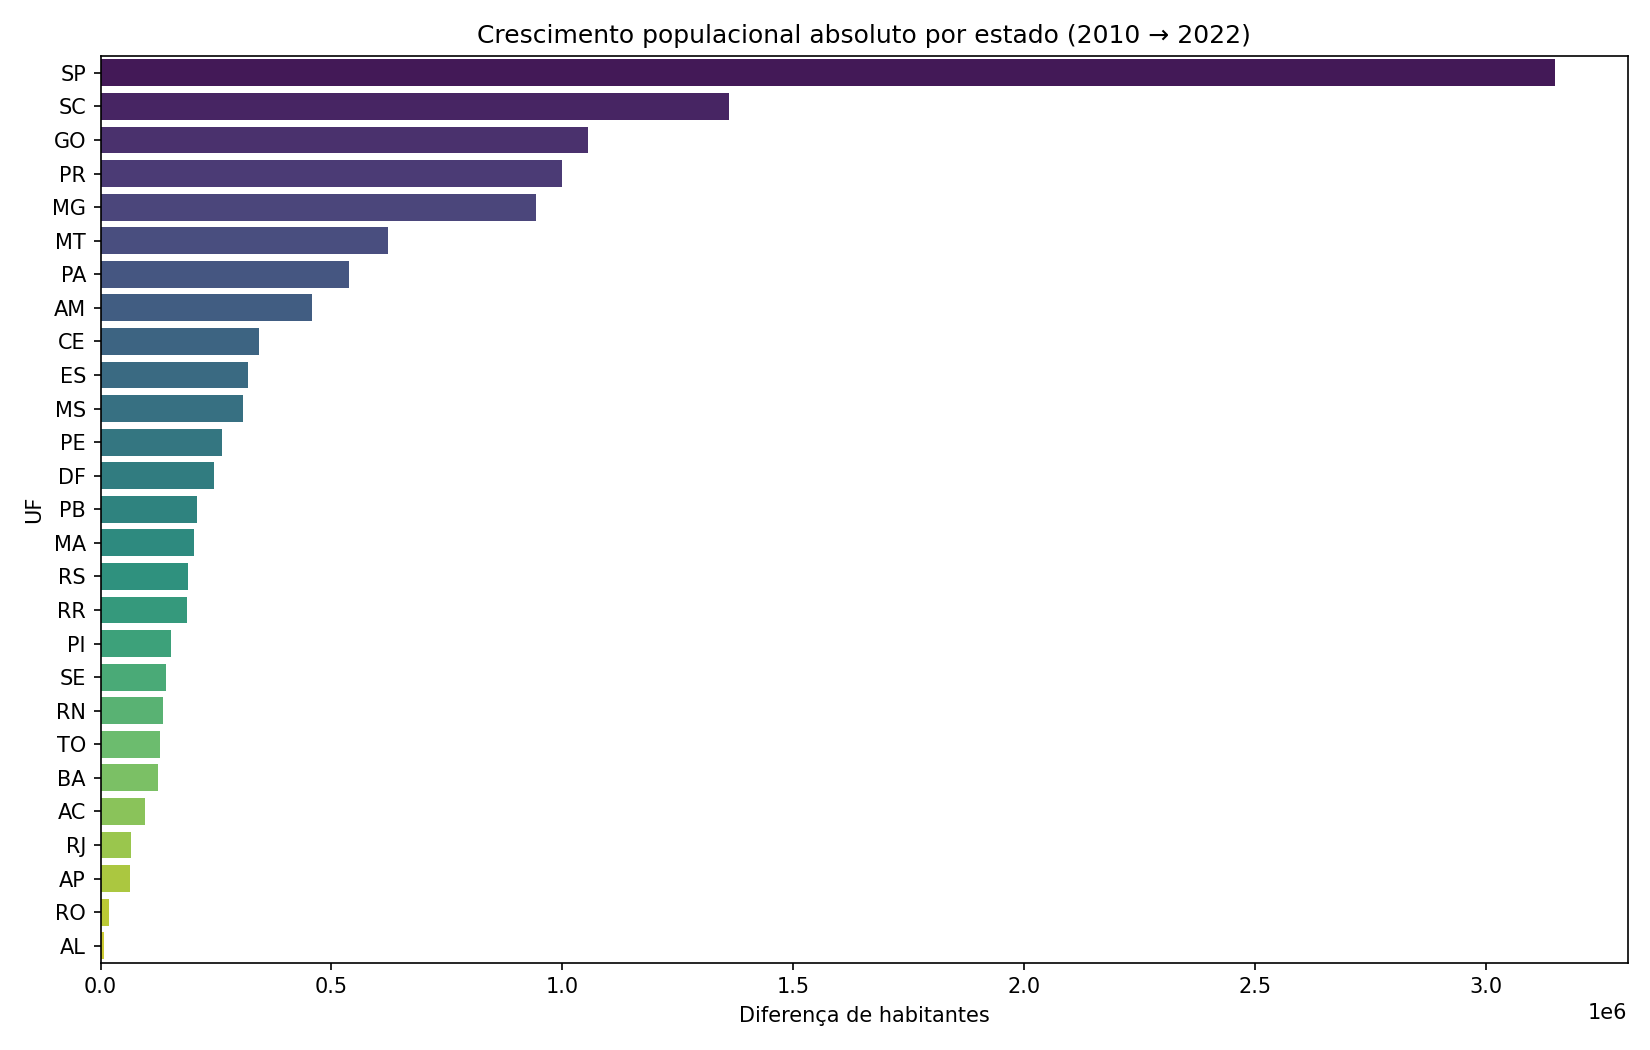

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=pop_estado, y="UF", x="diferenca_2010_2022", hue="UF", legend=False, palette="viridis", ax=ax)
ax.set_title("Crescimento populacional absoluto por estado (2010 → 2022)")
ax.set_xlabel("Diferença de habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.savefig("grafico_diferenca_todos_estados.png", dpi=150)
plt.show()